In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_simload
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import matplotlib.ticker as ticker

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

### read in SatGen data

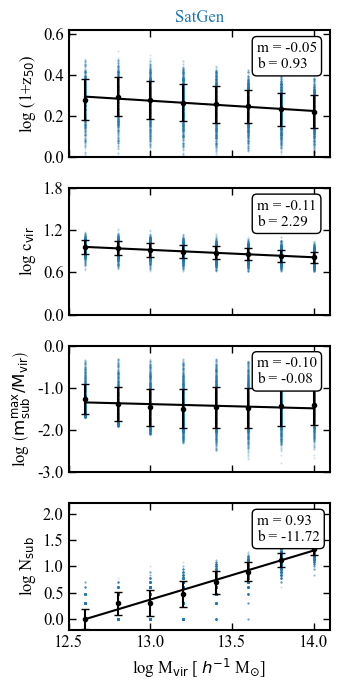

In [4]:
satgen500 = pd.read_csv("../../data/summary_tabs/satgen500_art.csv")
satnorm = jsm_simload.NormalizeData(satgen500, dataset_title="SatGen")
satnorm.plot_bestfit("../../figures/satgen_fit.pdf", col="C0")

In [5]:
rho_matz, rho_err_matz, N_hosts = jsm_simload.mass_binned_correlation([satnorm.df], xkey="log1pz50", ykey="Nsub", xlabel="log(1+z50)", ylabel="logN", make_plot=False)
rho_matc, rho_err_matc, _ = jsm_simload.mass_binned_correlation([satnorm.df], xkey="logc", ykey="Nsub", xlabel="log c", ylabel="logN", make_plot=False)
rho_matm, rho_err_matm, _ = jsm_simload.mass_binned_correlation([satnorm.df], xkey="MMs", ykey="Nsub", xlabel="log MMs", ylabel="logN", make_plot=False)

In [6]:
# fig, axes = plt.subplots(3, 1, figsize=(double_textwidth, double_textwidth), sharex=True, sharey=True)

# ### vanilla satgen
# axes[0].errorbar(logMvir_offset1, wrho_matz[0], yerr=wrho_err_matz[0], marker=".", fmt=".", capsize=3, c="lightblue")
# axes[1].errorbar(logMvir_offset1, wrho_matc[0], yerr=wrho_err_matc[0], marker=".", fmt=".", capsize=3, c="lightblue")
# axes[2].errorbar(logMvir_offset1, wrho_matm[0], yerr=wrho_err_matm[0], marker=".", fmt=".", capsize=3, c="lightblue")

# ### corrected satgen
# axes[0].errorbar(logMvir, rho_matz[0], yerr=rho_err_matz[0], marker=".", fmt=".", capsize=3, c="C0")
# axes[1].errorbar(logMvir, rho_matc[0], yerr=rho_err_matc[0], marker=".", fmt=".", capsize=3, c="C0")
# axes[2].errorbar(logMvir, rho_matm[0], yerr=rho_err_matm[0], marker=".", fmt=".", capsize=3, c="C0")

# axes[0].set_ylabel("$\\rho$ (N$_{\\rm sub}$, z$_{50}$)")
# axes[1].set_ylabel("$\\rho$ (N$_{\\rm sub}$, c$_{\\rm vir}$)")
# axes[2].set_ylabel("$\\rho$ (N$_{\\rm sub}$, m$_{\\rm sub}^{\\rm max}$)")
# axes[2].set_xlabel("log M$_{\\rm vir}$")

# axes[0].set_ylim(-1,1)
# axes[2].set_xlim(12.5, 14.1)

# for ax in axes.flatten():
#     ax.axhline(0, ls=":", lw=0.5, color="grey")
#     ax.axhline(0.5, ls=":", lw=0.5, color="grey")
#     ax.axhline(-0.5, ls=":", lw=0.5, color="grey")

### read in Bolshoi

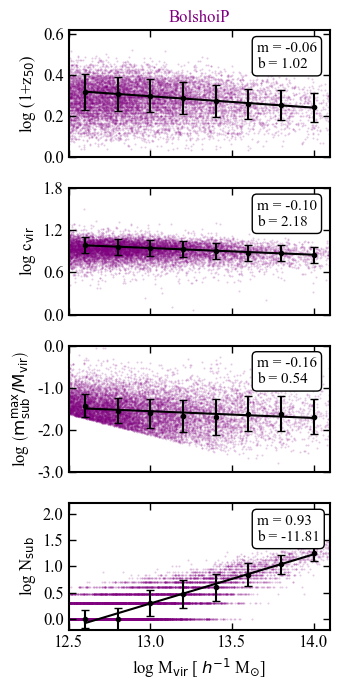

In [7]:
boltab = pd.read_csv("../../data/summary_tabs/BolshoiP.csv")
bolnorm = jsm_simload.NormalizeData(boltab, dataset_title="BolshoiP")
bolnorm.plot_bestfit("../../figures/bolshoi_fit.pdf", col="purple")

In [8]:
brho_matz, brho_err_matz, bN_hosts = jsm_simload.mass_binned_correlation([bolnorm.df], xkey="log1pz50", ykey="Nsub", xlabel="log(1+z50)", ylabel="logN", make_plot=False)
brho_matc, brho_err_matc, _ = jsm_simload.mass_binned_correlation([bolnorm.df], xkey="logc", ykey="Nsub", xlabel="log c", ylabel="logN", make_plot=False)
brho_matm, brho_err_matm, _ = jsm_simload.mass_binned_correlation([bolnorm.df], xkey="MMs", ykey="Nsub", xlabel="log MMs", ylabel="logN", make_plot=False)

### read in smdpl

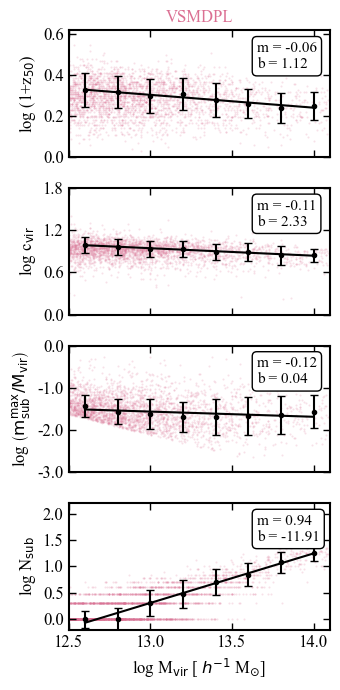

In [9]:
smmdpltab = pd.read_csv("../../data/summary_tabs/VSMPDL.csv")
smdnorm = jsm_simload.NormalizeData(smmdpltab, dataset_title="VSMDPL")
smdnorm.plot_bestfit("../../figures/vsmpdl_fit.pdf", col="palevioletred")

In [10]:
srho_matz, srho_err_matz, vN_hosts = jsm_simload.mass_binned_correlation([smdnorm.df], xkey="log1pz50", ykey="Nsub", xlabel="log(1+z50)", ylabel="logN", make_plot=False)
srho_matc, srho_err_matc, _ = jsm_simload.mass_binned_correlation([smdnorm.df], xkey="logc", ykey="Nsub", xlabel="log c", ylabel="logN", make_plot=False)
srho_matm, srho_err_matm, _ = jsm_simload.mass_binned_correlation([smdnorm.df], xkey="MMs", ykey="Nsub", xlabel="log MMs", ylabel="logN", make_plot=False)

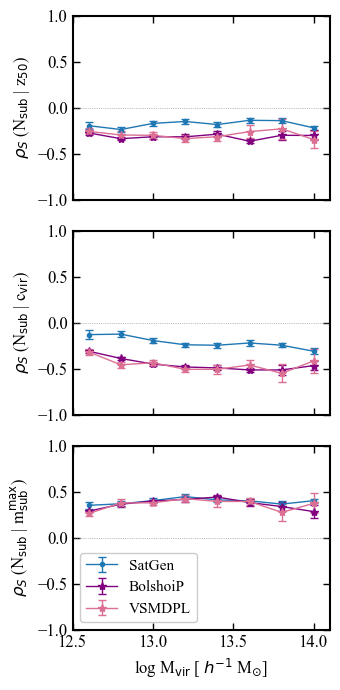

In [12]:
logMvir = np.linspace(12.6, 14, 8)

fig, axes = plt.subplots(3, 1, figsize=(single_textwidth, double_textwidth), sharex=True, sharey=True)

# ### vanilla satgen
# axes[0].errorbar(logMvir_offset1, wrho_matz[0], yerr=wrho_err_matz[0], marker=".", capsize=3, lw=1, c="lightblue")
# axes[1].errorbar(logMvir_offset1, wrho_matc[0], yerr=wrho_err_matc[0], marker=".", capsize=3, lw=1, c="lightblue")
# axes[2].errorbar(logMvir_offset1, wrho_matm[0], yerr=wrho_err_matm[0], marker=".", capsize=3, lw=1, c="lightblue", label="SatGen (uncorrected)")

### corrected satgen
axes[0].errorbar(logMvir, rho_matz[0], yerr=rho_err_matz[0], marker=".", capsize=3, lw=1, c="C0")
axes[1].errorbar(logMvir, rho_matc[0], yerr=rho_err_matc[0], marker=".", capsize=3, lw=1, c="C0")
axes[2].errorbar(logMvir, rho_matm[0], yerr=rho_err_matm[0], marker=".", capsize=3, lw=1, c="C0", label="SatGen")

### bolshoi
axes[0].errorbar(logMvir, brho_matz[0], yerr=brho_err_matz[0], marker="*", capsize=3, lw=1, c="purple")
axes[1].errorbar(logMvir, brho_matc[0], yerr=brho_err_matc[0], marker="*", capsize=3, lw=1, c="purple")
axes[2].errorbar(logMvir, brho_matm[0], yerr=brho_err_matm[0], marker="*", capsize=3, lw=1, c="purple", label="BolshoiP")

### vsmdpl
axes[0].errorbar(logMvir, srho_matz[0], yerr=srho_err_matz[0], marker="*", capsize=3, lw=1, c="palevioletred")
axes[1].errorbar(logMvir, srho_matc[0], yerr=srho_err_matc[0], marker="*", capsize=3, lw=1, c="palevioletred")
axes[2].errorbar(logMvir, srho_matm[0], yerr=srho_err_matm[0], marker="*", capsize=3, lw=1, c="palevioletred", label="VSMDPL")

axes[0].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | z$_{50}$)")
axes[1].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | c$_{\\rm vir}$)")
axes[2].set_ylabel("$\\rho_S$ (N$_{\\rm sub}$ | m$_{\\rm sub}^{\\rm max}$)")
axes[2].set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")

axes[0].set_ylim(-1,1)
axes[2].set_xlim(12.5, 14.1)
axes[2].legend(framealpha=1, fontsize=11)

for ax in axes.flatten():
    ax.axhline(0, ls=":", lw=0.5, color="grey")
    # ax.axhline(0.5, ls=":", lw=0.5, color="grey")
    # ax.axhline(-0.5, ls=":", lw=0.5, color="grey")

plt.tight_layout()
plt.savefig("../../figures/corr_comp.pdf", bbox_inches="tight")
plt.show()

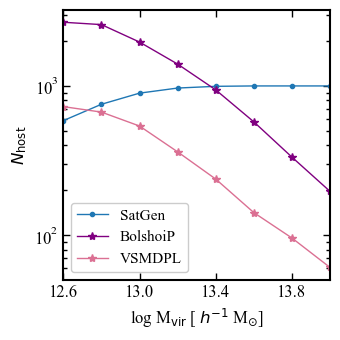

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(single_textwidth, single_textwidth), sharex=True, sharey=True)

axes.set_ylabel("$N_{\\rm host}$")
axes.set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")

axes.plot(logMvir, N_hosts, marker=".", lw=1, c="C0", label="SatGen")
axes.plot(logMvir, bN_hosts, marker="*", lw=1, c="purple", label="BolshoiP")
axes.plot(logMvir, vN_hosts, marker="*", lw=1, c="palevioletred", label="VSMDPL")

axes.set_yscale("log")

axes.set_xlim(12.6, 14.0)
axes.legend(framealpha=1, fontsize=11)
axes.set_xticks([12.6, 13.0, 13.4, 13.8])


plt.tight_layout()
plt.savefig("../../figures/Nhosts.pdf", bbox_inches="tight")
plt.show()

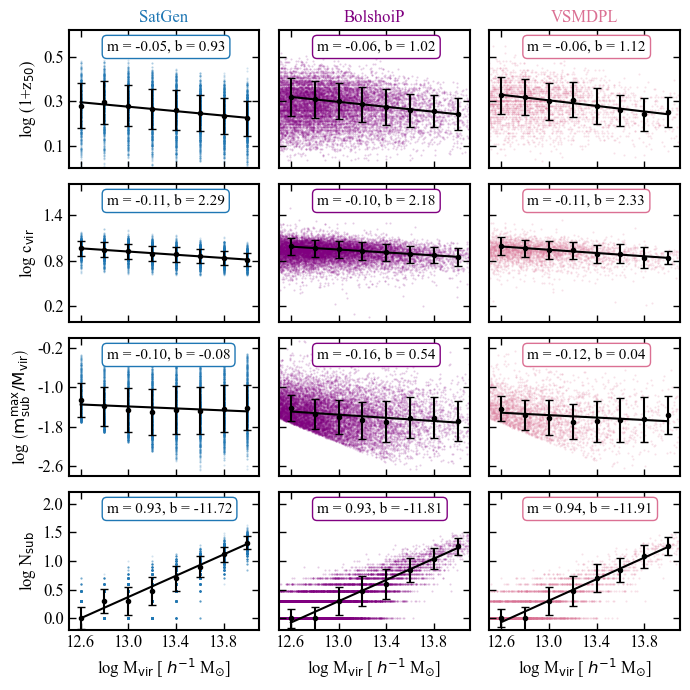

In [14]:
fig, ax = plt.subplots(4, 3, figsize=(double_textwidth, double_textwidth), sharex=True, sharey="row")

ax[0, 0].scatter(satnorm.df["logMvir"], satnorm.df["log1pz50"], marker=".", s=1, alpha=0.2, c="C0", rasterized=True)
ax[1, 0].scatter(satnorm.df["logMvir"], satnorm.df["logc"],     marker=".", s=1, alpha=0.2, c="C0", rasterized=True)
ax[2, 0].scatter(satnorm.df["logMvir"], satnorm.df["logMMs"],   marker=".", s=1, alpha=0.2, c="C0", rasterized=True)
ax[3, 0].scatter(satnorm.df["logMvir"], satnorm.df["logNsub"],  marker=".", s=1, alpha=0.2, c="C0", rasterized=True)

ax[0, 0].errorbar(satnorm.logMvir_bincenters, satnorm.log1pz50_med, yerr=satnorm.log1pz50_std, fmt=".", color="k", capsize=3)
ax[1, 0].errorbar(satnorm.logMvir_bincenters, satnorm.logc_med,     yerr=satnorm.logc_std,     fmt=".", color="k", capsize=3)
ax[2, 0].errorbar(satnorm.logMvir_bincenters, satnorm.logMMs_med,   yerr=satnorm.logMMs_std,   fmt=".", color="k", capsize=3)
ax[3, 0].errorbar(satnorm.logMvir_bincenters, satnorm.logNsub_med,  yerr=satnorm.logNsub_std,  fmt=".", color="k", capsize=3)

ax[0, 0].plot(satnorm.logMvir_smooth, satnorm.log1pz50_smooth, color="k")
ax[1, 0].plot(satnorm.logMvir_smooth, satnorm.logc_smooth,     color="k")
ax[2, 0].plot(satnorm.logMvir_smooth, satnorm.logMMs_smooth,   color="k")
ax[3, 0].plot(satnorm.logMvir_smooth, satnorm.logNsub_smooth,  color="k")

ax[0, 0].text(0.2, 0.85, s=f"m = {satnorm.m_log1pz50:.2f}, b = {satnorm.b_log1pz50:.2f}", fontsize=11, transform=ax[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="C0"))
ax[1, 0].text(0.2, 0.85, s=f"m = {satnorm.m_logc:.2f}, b = {satnorm.b_logc:.2f}",         fontsize=11, transform=ax[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="C0"))
ax[2, 0].text(0.2, 0.85, s=f"m = {satnorm.m_logMMs:.2f}, b = {satnorm.b_logMMs:.2f}",     fontsize=11, transform=ax[2, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="C0"))
ax[3, 0].text(0.2, 0.85, s=f"m = {satnorm.m_logNsub:.2f}, b = {satnorm.b_logNsub:.2f}",   fontsize=11, transform=ax[3, 0].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="C0"))

ax[0, 1].scatter(bolnorm.df["logMvir"], bolnorm.df["log1pz50"], marker=".", s=1, alpha=0.2, c="purple", rasterized=True)
ax[1, 1].scatter(bolnorm.df["logMvir"], bolnorm.df["logc"],     marker=".", s=1, alpha=0.2, c="purple", rasterized=True)
ax[2, 1].scatter(bolnorm.df["logMvir"], bolnorm.df["logMMs"],   marker=".", s=1, alpha=0.2, c="purple", rasterized=True)
ax[3, 1].scatter(bolnorm.df["logMvir"], bolnorm.df["logNsub"],  marker=".", s=1, alpha=0.2, c="purple", rasterized=True)

ax[0, 1].errorbar(bolnorm.logMvir_bincenters, bolnorm.log1pz50_med, yerr=bolnorm.log1pz50_std, fmt=".", color="k", capsize=3)
ax[1, 1].errorbar(bolnorm.logMvir_bincenters, bolnorm.logc_med,     yerr=bolnorm.logc_std,     fmt=".", color="k", capsize=3)
ax[2, 1].errorbar(bolnorm.logMvir_bincenters, bolnorm.logMMs_med,   yerr=bolnorm.logMMs_std,   fmt=".", color="k", capsize=3)
ax[3, 1].errorbar(bolnorm.logMvir_bincenters, bolnorm.logNsub_med,  yerr=bolnorm.logNsub_std,  fmt=".", color="k", capsize=3)

ax[0, 1].plot(bolnorm.logMvir_smooth, bolnorm.log1pz50_smooth, color="k")
ax[1, 1].plot(bolnorm.logMvir_smooth, bolnorm.logc_smooth,     color="k")
ax[2, 1].plot(bolnorm.logMvir_smooth, bolnorm.logMMs_smooth,   color="k")
ax[3, 1].plot(bolnorm.logMvir_smooth, bolnorm.logNsub_smooth,  color="k")

ax[0, 1].text(0.2, 0.85, s=f"m = {bolnorm.m_log1pz50:.2f}, b = {bolnorm.b_log1pz50:.2f}", fontsize=11, transform=ax[0, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="purple"))
ax[1, 1].text(0.2, 0.85, s=f"m = {bolnorm.m_logc:.2f}, b = {bolnorm.b_logc:.2f}",         fontsize=11, transform=ax[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="purple"))
ax[2, 1].text(0.2, 0.85, s=f"m = {bolnorm.m_logMMs:.2f}, b = {bolnorm.b_logMMs:.2f}",     fontsize=11, transform=ax[2, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="purple"))
ax[3, 1].text(0.2, 0.85, s=f"m = {bolnorm.m_logNsub:.2f}, b = {bolnorm.b_logNsub:.2f}",   fontsize=11, transform=ax[3, 1].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="purple"))

ax[0, 2].scatter(smdnorm.df["logMvir"], smdnorm.df["log1pz50"], marker=".", s=1, alpha=0.2, c="palevioletred", rasterized=True)
ax[1, 2].scatter(smdnorm.df["logMvir"], smdnorm.df["logc"],     marker=".", s=1, alpha=0.2, c="palevioletred", rasterized=True)
ax[2, 2].scatter(smdnorm.df["logMvir"], smdnorm.df["logMMs"],   marker=".", s=1, alpha=0.2, c="palevioletred", rasterized=True)
ax[3, 2].scatter(smdnorm.df["logMvir"], smdnorm.df["logNsub"],  marker=".", s=1, alpha=0.2, c="palevioletred", rasterized=True)

ax[0, 2].errorbar(smdnorm.logMvir_bincenters, smdnorm.log1pz50_med, yerr=smdnorm.log1pz50_std, fmt=".", color="k", capsize=3)
ax[1, 2].errorbar(smdnorm.logMvir_bincenters, smdnorm.logc_med,     yerr=smdnorm.logc_std,     fmt=".", color="k", capsize=3)
ax[2, 2].errorbar(smdnorm.logMvir_bincenters, smdnorm.logMMs_med,   yerr=smdnorm.logMMs_std,   fmt=".", color="k", capsize=3)
ax[3, 2].errorbar(smdnorm.logMvir_bincenters, smdnorm.logNsub_med,  yerr=smdnorm.logNsub_std,  fmt=".", color="k", capsize=3)

ax[0, 2].plot(smdnorm.logMvir_smooth, smdnorm.log1pz50_smooth, color="k")
ax[1, 2].plot(smdnorm.logMvir_smooth, smdnorm.logc_smooth,     color="k")
ax[2, 2].plot(smdnorm.logMvir_smooth, smdnorm.logMMs_smooth,   color="k")
ax[3, 2].plot(smdnorm.logMvir_smooth, smdnorm.logNsub_smooth,  color="k")


ax[0, 2].text(0.2, 0.85, s=f"m = {smdnorm.m_log1pz50:.2f}, b = {smdnorm.b_log1pz50:.2f}", fontsize=11, transform=ax[0, 2].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="palevioletred"))
ax[1, 2].text(0.2, 0.85, s=f"m = {smdnorm.m_logc:.2f}, b = {smdnorm.b_logc:.2f}",         fontsize=11, transform=ax[1, 2].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="palevioletred"))
ax[2, 2].text(0.2, 0.85, s=f"m = {smdnorm.m_logMMs:.2f}, b = {smdnorm.b_logMMs:.2f}",     fontsize=11, transform=ax[2, 2].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="palevioletred"))
ax[3, 2].text(0.2, 0.85, s=f"m = {smdnorm.m_logNsub:.2f}, b = {smdnorm.b_logNsub:.2f}",   fontsize=11, transform=ax[3, 2].transAxes, bbox=dict(boxstyle="round", facecolor="white", edgecolor="palevioletred"))

ax[0, 0].set_ylabel("log (1+z$_{50}$)")
ax[1, 0].set_ylabel("log c$_{\\rm vir}$")
ax[2, 0].set_ylabel(r"log $\left( \mathrm{m}_{\rm sub}^{\rm max} / \mathrm{M}_{\rm vir} \right)$")   
ax[3, 0].set_ylabel("log N$_{\\rm sub}$")

ax[0, 0].set_ylim(0, 0.62)
ax[1, 0].set_ylim(0, 1.8)
ax[2, 0].set_ylim(-2.8, 0)
ax[3, 0].set_ylim(-0.2, 2.2)
ax[3, 0].set_xlim(12.5, 14.1)

ax[0, 0].set_yticks([0.1, 0.3, 0.5])
ax[1, 0].set_yticks([0.2, 0.8, 1.4])
ax[2, 0].set_yticks([-2.6, -1.8, -1, -0.2])
ax[3, 0].set_yticks([0.0, 0.5, 1.0, 1.5, 2.0])

ax[3, 0].set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")
ax[3, 1].set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")
ax[3, 2].set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")

ax[0, 0].set_title("SatGen", c="C0")
ax[0, 1].set_title("BolshoiP", c="purple")
ax[0, 2].set_title("VSMDPL", c="palevioletred")

for a in ax.flatten():
    a.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

ax[3, 0].set_xticks([12.6, 13.0, 13.4, 13.8])


plt.tight_layout()
plt.savefig("../../figures/scaling_relations.pdf", bbox_inches="tight")
plt.show()